In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

def clean_air_quality_data(file_path):
    # Load dataset
    df = pd.read_csv(file_path)
    
    # Convert Date column to datetime
    df['Date'] = pd.to_datetime(df['Date'])
    
    # Handle missing values
    num_imputer = SimpleImputer(strategy='median')  # Using median for numerical columns
    cat_imputer = SimpleImputer(strategy='most_frequent')  # Using most frequent for categorical
    
    # Impute numerical features
    num_cols = df.select_dtypes(include=['float64']).columns
    df[num_cols] = num_imputer.fit_transform(df[num_cols])
    
    # Impute categorical features
    df['AQI_Bucket'] = cat_imputer.fit_transform(df[['AQI_Bucket']]).ravel()
    
    # Encode categorical variables
    label_enc = LabelEncoder()
    df['City'] = label_enc.fit_transform(df['City'])
    df['AQI_Bucket'] = label_enc.fit_transform(df['AQI_Bucket'])
    
    # Return cleaned dataframe
    return df

# Usage
file_path = "./city_day.csv"
cleaned_df = clean_air_quality_data(file_path)
print(cleaned_df.head())


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

   City       Date  PM2.5   PM10     NO    NO2    NOx    NH3     CO    SO2  \
0     0 2015-01-01  48.57  95.68   0.92  18.22  17.15  15.85   0.92  27.64   
1     0 2015-01-02  48.57  95.68   0.97  15.69  16.46  15.85   0.97  24.55   
2     0 2015-01-03  48.57  95.68  17.40  19.30  29.70  15.85  17.40  29.07   
3     0 2015-01-04  48.57  95.68   1.70  18.48  17.97  15.85   1.70  18.59   
4     0 2015-01-05  48.57  95.68  22.10  21.42  37.76  15.85  22.10  39.33   

       O3  Benzene  Toluene  Xylene    AQI  AQI_Bucket  
0  133.36     0.00     0.02    0.00  118.0           1  
1   34.06     3.68     5.50    3.77  118.0           1  
2   30.70     6.80    16.40    2.25  118.0           1  
3   36.08     4.43    10.14    1.00  118.0           1  
4   39.31     7.01    18.89    2.78  118.0           1  


In [2]:
# LSTM

In [6]:
cleaned_df.to_csv('./AQI_dataset_cleaned_lstm.csv', index=False)

In [8]:
# Load cleaned dataset
file_path = "./AQI_dataset_cleaned_lstm.csv"
df = pd.read_csv(file_path)

# Convert Date to datetime format
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Create cyclical features for better temporal representation
df['day_of_year'] = df.index.dayofyear  # More effective than just day of the month

def create_cyclical_features(df, column, max_val):
    df[column + '_sin'] = np.sin(2 * np.pi * df[column] / max_val)
    df[column + '_cos'] = np.cos(2 * np.pi * df[column] / max_val)
    return df

df = create_cyclical_features(df, 'day_of_year', 365)  # Account for full year cycles

# Drop the raw day_of_year column
df.drop(columns=['day_of_year'], inplace=True)

# Select relevant numerical features for LSTM
features = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 
            'day_of_year_sin', 'day_of_year_cos']  # Include cyclical features

scaler = MinMaxScaler()
df[features] = scaler.fit_transform(df[features])

# Define target variable (AQI) and normalize it
df['AQI'] = scaler.fit_transform(df[['AQI']])

# Function to create sequences for LSTM
def create_sequences(data, target, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(target[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 10  # Using 10 past days to predict the next
X, y = create_sequences(df[features].values, df['AQI'].values, seq_length)

# Split into training and testing sets
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Build LSTM Model
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(seq_length, len(features))),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25, activation='relu'),
    Dense(1)
])

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Train the model
model.fit(X_train, y_train, epochs=20, batch_size=16, validation_data=(X_test, y_test))

# Save the trained model
model.save("./lstm_air_quality.h5")

print("LSTM Model Training Complete!")


Epoch 1/20
1476/1476 [==============================] - 17s 9ms/step - loss: 0.0020 - val_loss: 7.8995e-04
Epoch 2/20
1476/1476 [==============================] - 13s 9ms/step - loss: 0.0015 - val_loss: 6.3115e-04
Epoch 3/20
1476/1476 [==============================] - 13s 9ms/step - loss: 0.0012 - val_loss: 4.2803e-04
Epoch 4/20
1476/1476 [==============================] - 14s 10ms/step - loss: 0.0011 - val_loss: 4.5573e-04
Epoch 5/20
1476/1476 [==============================] - 16s 11ms/step - loss: 0.0011 - val_loss: 4.0694e-04
Epoch 6/20
1476/1476 [==============================] - 15s 10ms/step - loss: 0.0011 - val_loss: 6.9571e-04
Epoch 7/20
1476/1476 [==============================] - 14s 10ms/step - loss: 0.0011 - val_loss: 3.9781e-04
Epoch 8/20
1476/1476 [==============================] - 14s 10ms/step - loss: 0.0010 - val_loss: 4.8560e-04
Epoch 9/20
1476/1476 [==============================] - 16s 11ms/step - loss: 0.0010 - val_loss: 3.7191e-04
Epoch 10/20
1476/1476 [========

C:\Python311\Lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


185/185 [==============================] - 2s 5ms/step
Mean Squared Error: 0.0004
Mean Absolute Error: 0.0123
R² Score: 0.8466
Root Mean Squared Error (RMSE): 0.01896028027594273


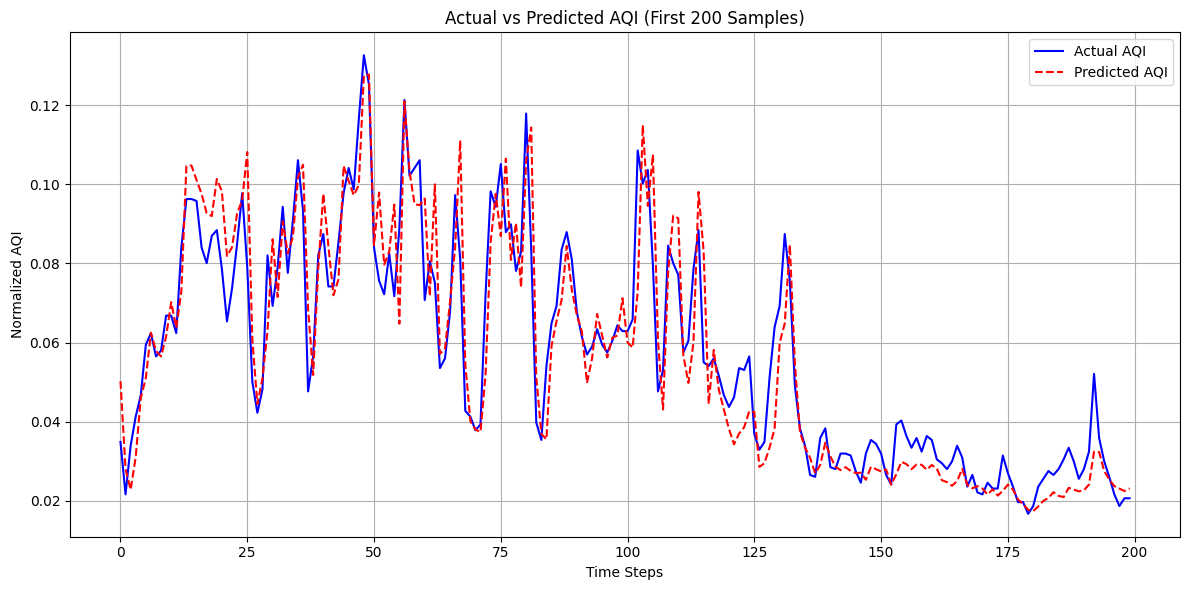

In [9]:
# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

# Plot a subset of test results for clarity (e.g., first 200 predictions)
plt.figure(figsize=(12, 6))
plt.plot(y_test[:200], label='Actual AQI', color='blue')
plt.plot(y_pred[:200], label='Predicted AQI', color='red', linestyle='dashed')
plt.title('Actual vs Predicted AQI (First 200 Samples)')
plt.xlabel('Time Steps')
plt.ylabel('Normalized AQI')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
